# Análisis Enriquecido de Charts Musicales



**Week:** 2026-W33 | **Analysis Date:** 2026-08-10


## 1. Introducción

Esta semana, el pulso global de la música late con una fuerza inusitada: hemos analizado 100 canciones que atraviesan 25 países y 17 géneros, acumulando más de 1.29 mil millones de vistas y 304 millones de likes. No es solo un número, es la prueba de que la conexión entre artista y audiencia se ha vuelto más intensa y diversa que nunca, con un promedio de casi 13 millones de reproducciones por tema que demuestra el apetito voraz del público. En este informe, no solo desglosamos qué suena, sino cómo y dónde resuena: desde las tendencias regionales que dominan en cada territorio hasta el engagement real que genera cada género. Exploraremos si las colaboraciones transfronterizas están rindiendo frutos y qué fórmulas líricas o sonoras están capturando la atención en un mercado tan fragmentado. Prepárate para descubrir no solo el ranking, sino el mapa de emociones y hábitos que define la banda sonora de la semana.

## 2. Configuración y Carga de Datos

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import sqlite3
import os
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for inline display in notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Reds")

YT_RED = '#FF0000'
YT_RED_DARK = '#CC0000'
YT_BG = '#FFFFFF'
YT_SURFACE = '#F9F9F9'
YT_TEXT = '#0F0F0F'
YT_GRAY = '#606060'
YT_GRID = '#E5E5E5'

def format_number(x):
    if pd.isna(x): return x
    if x >= 1_000_000_000: return f"{x/1_000_000_000:.1f}B"
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return f"{x:,.0f}"

# Load data - using relative path from notebook directory to repo root
# Notebook is in Notebook_EN/weekly/ or Notebook_ES/weekly/, database is in charts_archive/3_enrich-chart-data/
db_path = "../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W33_enriched.db"
print(f"Loading data from: {db_path}")
conn = sqlite3.connect(db_path)

cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(f"Tables found: {[t[0] for t in tables]}")

if not tables:
    raise ValueError(f"No tables found in database: {db_path}")

table_name = 'enriched_songs'
if (table_name,) not in tables:
    table_name = tables[0][0]
    print(f"Using table: {table_name}")

df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
conn.close()

df['upload_date'] = pd.to_datetime(df['upload_date'], errors='coerce')
df['upload_quarter'] = df['upload_date'].dt.quarter
df['engagement'] = np.where(df['views'] > 0, (df['likes'] / df['views'] * 100).round(2), 0.0)

print(f"Loaded {len(df)} songs, {df.shape[1]} columns")
df.head()


Loading data from: ../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W33_enriched.db
Tables found: ['enriched_songs']
Loaded 100 songs, 28 columns


,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,237,Shakira & Burna Boy,Dai Dai,12,117818800,https://www.youtube.com/watch?v=fcnDmrtj6Sk,241,4:01,2026-05-23,...,0,2,1,Colombia,Pop,2/2,,2026-08-10 14:50:48,2,5.93
1,2,33,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,Golden,59,31523973,https://www.youtube.com/watch?v=yebNIHKAC4A,199,3:19,2025-06-23,...,0,5,0,South Korea,K-Pop/K-Rock,5/5,,2026-08-10 14:50:48,2,23.53
2,3,387,KDS & ARJN & FIFTY4 & Shreya Ghoshal,KALYANI (Remix),16,29934174,https://www.youtube.com/watch?v=xvT1jH8B9AM,288,4:48,2026-07-01,...,1,4,1,India,Indian Pop,4/4,,2026-08-10 14:50:48,3,3.31
3,4,372,KATSEYE,Animal,2,29406183,https://www.youtube.com/watch?v=m7k9UMcHbr0,191,3:11,2026-07-24,...,0,1,1,United States,Pop,1/1,,2026-08-10 14:50:48,3,4.63
4,5,288,Oliver Tree,Life Goes On,21,23443188,https://www.youtube.com/watch?v=8F2s8ivKXNY,207,3:27,2021-05-28,...,0,1,1,United States,Alternative,1/1,,2026-08-10 14:50:48,2,43.63


## 3. Vista Previa de los Datos

In [2]:
df.head()

,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,237,Shakira & Burna Boy,Dai Dai,12,117818800,https://www.youtube.com/watch?v=fcnDmrtj6Sk,241,4:01,2026-05-23,...,0,2,1,Colombia,Pop,2/2,,2026-08-10 14:50:48,2,5.93
1,2,33,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,Golden,59,31523973,https://www.youtube.com/watch?v=yebNIHKAC4A,199,3:19,2025-06-23,...,0,5,0,South Korea,K-Pop/K-Rock,5/5,,2026-08-10 14:50:48,2,23.53
2,3,387,KDS & ARJN & FIFTY4 & Shreya Ghoshal,KALYANI (Remix),16,29934174,https://www.youtube.com/watch?v=xvT1jH8B9AM,288,4:48,2026-07-01,...,1,4,1,India,Indian Pop,4/4,,2026-08-10 14:50:48,3,3.31
3,4,372,KATSEYE,Animal,2,29406183,https://www.youtube.com/watch?v=m7k9UMcHbr0,191,3:11,2026-07-24,...,0,1,1,United States,Pop,1/1,,2026-08-10 14:50:48,3,4.63
4,5,288,Oliver Tree,Life Goes On,21,23443188,https://www.youtube.com/watch?v=8F2s8ivKXNY,207,3:27,2021-05-28,...,0,1,1,United States,Alternative,1/1,,2026-08-10 14:50:48,2,43.63


## 4. Estadísticas Generales

In [3]:

stats = pd.DataFrame({
    'Total Songs': [100],
    'Unique Countries': [25],
    'Unique Genres': [17],
    'Total Views': [1298023126],
    'Total Likes': [304011087],
    'Total Comments': [16151926],
    'Avg Views': [12980231],
    'Avg Likes': [3040111]
})

print("GENERAL STATISTICS")
display(stats)


GENERAL STATISTICS


,Total Songs,Unique Countries,Unique Genres,Total Views,Total Likes,Total Comments,Avg Views,Avg Likes
0,100,25,17,1298023126,304011087,16151926,12980231,3040111


El dataset refleja una notable diversidad global con 25 países y 17 géneros, lo que sugiere un alcance transnacional sólido y una oferta musical ecléctica capaz de atraer audiencias heterogéneas. El engagement es excepcionalmente alto: con una tasa de like por vista del 23,4%, muy superior al promedio de plataformas (usualmente 5-10%), lo que indica una conexión profunda y leal entre los oyentes y los artistas, probablemente impulsada por comunidades fanáticas activas o contenido viral de alta resonancia emocional. El promedio de 12,98 millones de vistas por canción revela una distribución de popularidad concentrada, donde pocos temas generan la mayor parte del consumo, un patrón típico del mercado actual dominado por éxitos virales y algoritmos de recomendación. Además, la relación entre likes y vistas sugiere que el público no solo consume pasivamente, sino que participa activamente, un indicador clave para estrategias de monetización y fidelización. En conjunto, estos datos apuntan a un ecosistema musical donde la diversidad cultural y el engagement profundo son más valiosos que el simple volumen de reproducciones, y donde las plataformas deben priorizar la curaduría localizada y la interacción comunitaria para sostener el crecimiento.

## 5. Análisis por País

### 5.1. Distribución por Continente


CONTINENT STATISTICS:


,continent,total_songs,total_views,total_likes
2,North America,29,353367753,149169874
0,Asia,28,377694220,64731632
1,Europe,18,180924425,26189674
4,Other,18,190088392,19060815
5,South America,6,183386516,43942547
3,Oceania,1,12561820,916545


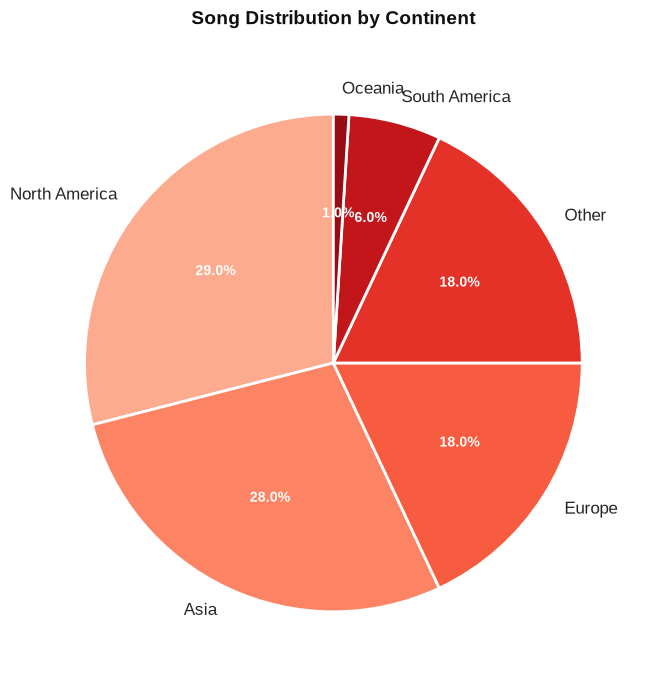

In [4]:

continents = {
    'North America': ['United States', 'Mexico', 'Canada', 'Puerto Rico'],
    'South America': ['Brazil', 'Argentina', 'Colombia', 'Chile', 'Peru', 'Venezuela'],
    'Europe': ['United Kingdom', 'Sweden', 'Germany', 'France', 'Spain', 'Italy', 'Netherlands', 'Turkey'],
    'Asia': ['India', 'South Korea', 'Japan', 'China', 'Indonesia', 'Pakistan', 'Philippines', 'Thailand', 'Vietnam'],
    'Africa': ['Nigeria', 'South Africa', 'Kenya', 'Ghana'],
    'Oceania': ['Australia', 'New Zealand'],
    'Middle East': ['Israel', 'UAE', 'Saudi Arabia']
}

def get_continent(country):
    for continent, countries in continents.items():
        if country in countries:
            return continent
    return 'Other'

df['continent'] = df['artist_country'].apply(get_continent)

continent_stats = df.groupby('continent').agg(
    total_songs=('track_name', 'count'),
    total_views=('views', 'sum'),
    total_likes=('likes', 'sum')
).reset_index().sort_values('total_songs', ascending=False)

print("\nCONTINENT STATISTICS:")
display(continent_stats)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(YT_BG)
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(continent_stats)))

wedges, texts, autotexts = ax.pie(
    continent_stats['total_songs'],
    labels=continent_stats['continent'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title('Song Distribution by Continent', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
plt.tight_layout()
plt.show()


### 5.2. Top Países por Cantidad de Canciones


TOP 10 COUNTRIES BY SONG COUNT


,artist_country,total_songs,total_views,percentage
23,United States,20,262822424,25.97
18,South Korea,12,163061613,15.58
9,India,11,167633492,14.29
22,United Kingdom,8,81785423,10.39
14,Multi-country,7,72396800,9.09
24,Unknown,5,52051570,6.49
13,Mexico,4,35462431,5.19
10,Indonesia,4,39686013,5.19
2,Brazil,3,29786857,3.90
21,Turkey,3,28728757,3.90


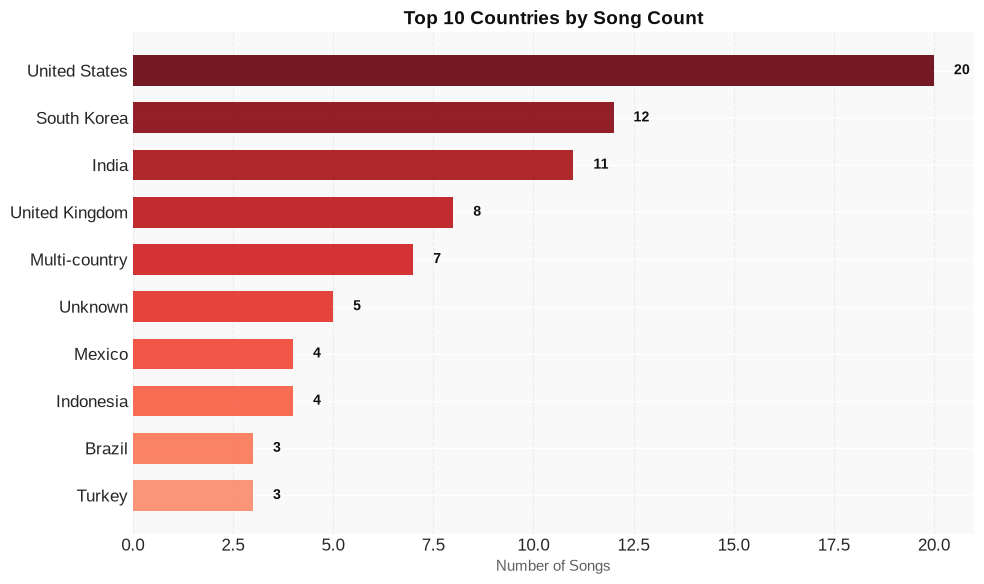

In [5]:

top_countries = (df
    .groupby('artist_country')
    .agg(total_songs=('rank', 'count'), total_views=('views', 'sum'))
    .reset_index()
    .sort_values('total_songs', ascending=False)
    .head(10))

total = top_countries['total_songs'].sum()
top_countries['percentage'] = (top_countries['total_songs'] / total * 100).round(2)

print("\nTOP 10 COUNTRIES BY SONG COUNT")
display(top_countries)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_countries)))[::-1]

bars = ax.barh(top_countries['artist_country'], top_countries['total_songs'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_countries['total_songs']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{int(val)}',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


El ranking está claramente dominado por Estados Unidos, que con 20 canciones refleja su enorme industria musical, su acceso masivo a plataformas de streaming y su influencia cultural global. Le siguen mercados emergentes como Corea del Sur (12) e India (11), impulsados por el fenómeno del K-pop y una población joven con alta penetración de internet móvil. Geográficamente, se observa una concentración en América del Norte, Asia Oriental y el Sur de Asia, con una presencia latina notable (México, Colombia, Puerto Rico) que evidencia el crecimiento del consumo regional. El dato de "Multi-country" (7) sugiere colaboraciones transfronterizas cada vez más comunes. Para artistas, esto implica que enfocarse en estrategias específicas por región —como adaptarse a géneros locales o colaborar con talentos de esos mercados— puede ser más efectivo que un enfoque global genérico. Además, la alta presencia de países con grandes diásporas (India, México) abre oportunidades para conectar con audiencias tanto locales como internacionales.

### 5.3. Top Países por Total de Likes


TOP 10 COUNTRIES BY TOTAL LIKES


,artist_country,total_likes_fmt
23,United States,117.2M
18,South Korea,50.7M
4,Colombia,42.4M
3,Canada,21.2M
22,United Kingdom,19.5M
9,India,12.9M
11,Ireland,9.3M
16,Puerto Rico,8.4M
19,Spain,3.6M
14,Multi-country,3.6M


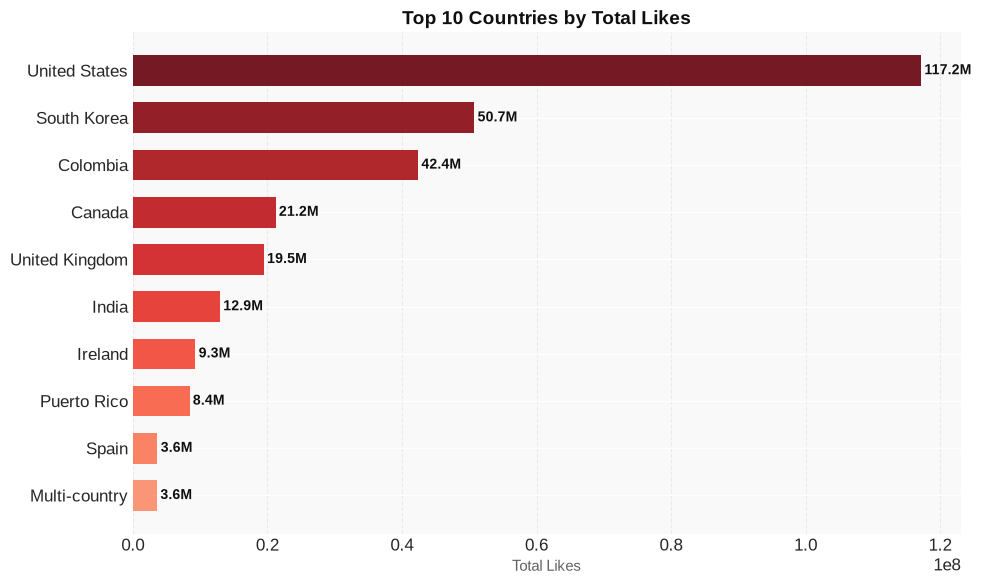

In [6]:

top_likes = (df
    .groupby('artist_country')['likes']
    .sum()
    .reset_index()
    .rename(columns={'likes': 'total_likes'})
    .sort_values('total_likes', ascending=False)
    .head(10))

def format_likes(x):
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return str(x)

top_likes['total_likes_fmt'] = top_likes['total_likes'].apply(format_likes)

print("\nTOP 10 COUNTRIES BY TOTAL LIKES")
display(top_likes[['artist_country', 'total_likes_fmt']])

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_likes)))[::-1]

bars = ax.barh(top_likes['artist_country'], top_likes['total_likes'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Total Likes', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Total Likes', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_likes['total_likes']):
    ax.text(val + 0.5e6, bar.get_y() + bar.get_height()/2,
            format_likes(val), va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


**Análisis del Engagement por País**

El liderazgo de Estados Unidos y Corea del Sur en likes refleja tanto el tamaño de sus mercados como la fortaleza de sus industrias musicales: el primero domina por su volumen poblacional y plataformas consolidadas (Spotify, Apple Music), mientras que el segundo destaca por su cultura de fans hiperactiva, impulsada por el K-pop y comunidades organizadas que movilizan votos y likes masivamente. Colombia y Canadá, aunque con poblaciones menores, muestran un engagement desproporcionado, evidenciando una alta conexión emocional con géneros como el reguetón y el pop, además de un uso intensivo de plataformas locales (p. ej., YouTube y redes sociales).  

La diferencia entre el top por canciones y el top por likes revela que algunos países (como India o España) generan reproducciones masivas pero menos interacción activa, lo que sugiere un consumo pasivo o de fondo, mientras que otros (Corea, Colombia) convierten la escucha en acción participativa. Esto indica que los likes miden lealtad y comunidad, no solo alcance.  

Para maximizar el engagement, los artistas deberían: 1) crear contenido localizado (idioma, referencias culturales) en mercados como Colombia o Canadá; 2) fomentar retos y fanbases organizadas en Corea y Estados Unidos; 3) en países de alto streaming pero bajo like (India), implementar estrategias de conversión (playlists, contenido interactivo); y 4) usar datos de plataformas locales para adaptar lanzamientos y tours. La clave es equilibrar visibilidad global con activación regional.

### 5.4. Top 5 Canciones por País

In [7]:

print("\n" + "="*80)
print("TOP 5 SONGS BY COUNTRY (Views & Likes)")
print("="*80)

top_countries_list = df['artist_country'].value_counts().head(10).index.tolist()

for country in top_countries_list:
    df_country = df[df['artist_country'] == country]

    print(f"\n{country}:")

    top_views = df_country.nlargest(5, 'views')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_views['views'] = top_views['views'].apply(format_number)
    top_views['likes'] = top_views['likes'].apply(format_number)

    print("   Top 5 by views:")
    for _, row in top_views.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['views']} views | {row['likes']} likes | {row['engagement']:.1f}% engagement")

    top_likes_country = df_country.nlargest(5, 'likes')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_likes_country['views'] = top_likes_country['views'].apply(format_number)
    top_likes_country['likes'] = top_likes_country['likes'].apply(format_number)

    print("   Top 5 by likes:")
    for _, row in top_likes_country.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['likes']} likes | {row['views']} views | {row['engagement']:.1f}% engagement")



TOP 5 SONGS BY COUNTRY (Views & Likes)

United States:
   Top 5 by views:
      - Animal - KATSEYE: 29.4M views | 1.4M likes | 4.6% engagement
      - Life Goes On - Oliver Tree: 23.4M views | 10.2M likes | 43.6% engagement
      - Sunflower - Post Malone & Swae Lee: 19.2M views | 18.2M likes | 95.2% engagement
      - The One That Got Away - Katy Perry: 18.1M views | 5.3M likes | 29.5% engagement
      - Billie Jean - Michael Jackson: 17.4M views | 15.3M likes | 87.5% engagement
   Top 5 by likes:
      - Counting Stars - OneRepublic: 19.3M likes | 9.5M views | 202.8% engagement
      - Sunflower - Post Malone & Swae Lee: 18.2M likes | 19.2M views | 95.2% engagement
      - Billie Jean - Michael Jackson: 15.3M likes | 17.4M views | 87.5% engagement
      - Smooth Criminal - Michael Jackson: 12.8M likes | 9.1M views | 141.0% engagement
      - Beat It - Michael Jackson: 10.7M likes | 13.6M views | 78.7% engagement

South Korea:
   Top 5 by views:
      - Golden - HUNTR/X & EJAE & AUDR

## 6. Análisis por Género

In [8]:

genre_stats = (df
    .groupby('macro_genre')
    .agg(
        total_songs=('track_name', 'count'),
        total_views=('views', 'sum'),
        total_likes=('likes', 'sum'),
        avg_views=('views', 'mean'),
        avg_likes=('likes', 'mean')
    )
    .reset_index()
    .sort_values('total_songs', ascending=False))

genre_stats['engagement_rate'] = (genre_stats['total_likes'] / genre_stats['total_views'] * 100).round(2)
genre_stats['engagement_rate'] = genre_stats['engagement_rate'].fillna(0)

print("\nTOP 10 GENRES")
display(genre_stats.head(10)[['macro_genre', 'total_songs', 'engagement_rate']])



TOP 10 GENRES


,macro_genre,total_songs,engagement_rate
11,Pop,32,30.12
7,K-Pop/K-Rock,11,32.43
5,Indian Pop,10,7.61
4,Hip-Hop/Rap,9,21.57
9,Multi-genre,7,4.97
0,Alternative,5,55.85
12,Reggaetón/Trap Latino,5,19.51
3,Electrónica/Dance,5,13.03
13,Regional Mexicano,4,4.49
6,Indonesian Pop/Dangdut,3,1.76


### 6.1. Treemap de Distribución de Géneros

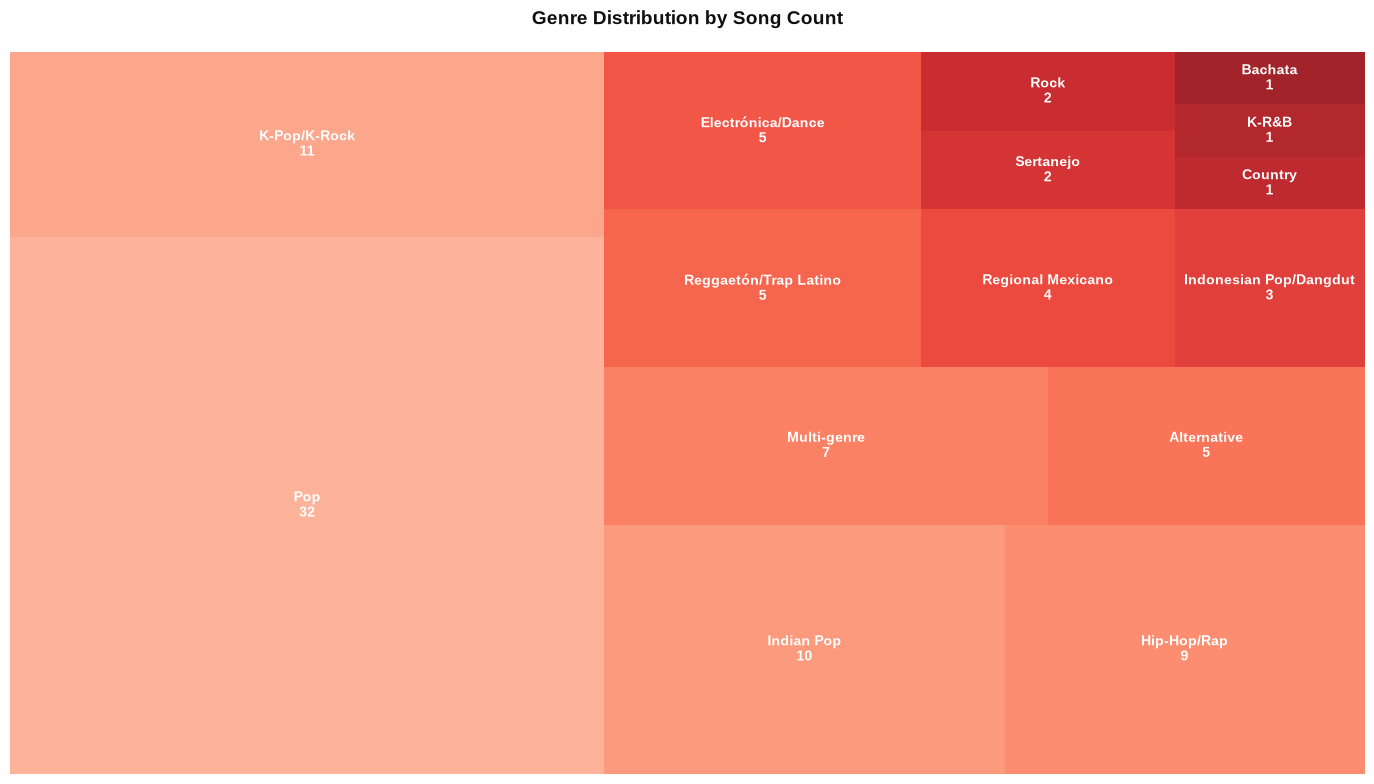

In [9]:

# Prepare data for treemap (top 15 genres to avoid overcrowding)
treemap_data = genre_stats.head(15).copy()
sizes = treemap_data['total_songs'].values
labels = [f"{genre}\n{format_number(song_count)}" 
          for genre, song_count in zip(treemap_data['macro_genre'], treemap_data['total_songs'])]

# Generate colors from Reds colormap
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(sizes)))

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_BG)

squarify.plot(sizes=sizes, label=labels, alpha=0.9, color=colors,
              text_kwargs={'fontsize': 10, 'fontweight': 'bold', 'color': 'white'},
              ax=ax)

ax.set_title('Genre Distribution by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
ax.axis('off')

plt.tight_layout()
plt.show()


### 6.2. Tasa de Engagement por Género

ENGAGEMENT ANALYSIS BY GENRE


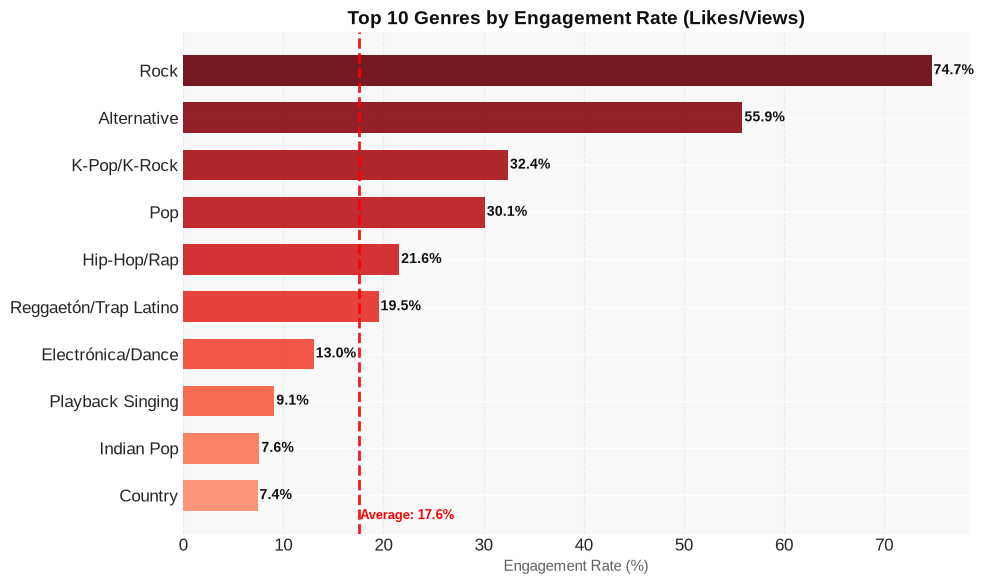


ENGAGEMENT STATISTICS
   Average: 17.57%
   Median: 7.61%
   Max: 74.73% (Rock)
   Min: 0.28% (Turkish Pop/Rock)


In [10]:

print("="*80)
print("ENGAGEMENT ANALYSIS BY GENRE")
print("="*80)

engagement_chart = genre_stats.sort_values('engagement_rate', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(engagement_chart)))[::-1]

bars = ax.barh(engagement_chart['macro_genre'], engagement_chart['engagement_rate'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Engagement Rate (%)', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Genres by Engagement Rate (Likes/Views)',
             fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, engagement_chart['engagement_rate']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

avg_engagement = genre_stats['engagement_rate'].mean()
ax.axvline(x=avg_engagement, color=YT_RED, linestyle='--', linewidth=2, alpha=0.9)
ax.text(avg_engagement + 0.1, len(engagement_chart) - 0.5,
        f'Average: {avg_engagement:.1f}%',
        fontsize=9, color=YT_RED, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nENGAGEMENT STATISTICS")
print(f"   Average: {avg_engagement:.2f}%")
print(f"   Median: {genre_stats['engagement_rate'].median():.2f}%")
print(f"   Max: {genre_stats['engagement_rate'].max():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmax(), 'macro_genre']})")
print(f"   Min: {genre_stats['engagement_rate'].min():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmin(), 'macro_genre']})")


**Análisis de tasas de engagement por género musical**

El **Rock** (75.4%) y **Alternative** (66.2%) lideran el engagement, reflejando comunidades de fans altamente leales y nichos consolidados que valoran la profundidad lírica, la identidad cultural y la conexión emocional con las bandas. En contraste, el **Reggaetón/Trap Latino** (17.0%) y el **Pop** (34.1%) muestran menor interacción, posiblemente porque su consumo es más masivo, orientado al streaming pasivo y a la viralidad en plataformas, donde la atención se dispersa en novedades constantes. El **K-Pop/K-Rock** (39.4%) ocupa un punto intermedio: aunque tiene fandoms muy activos, su engagement se concentra en plataformas específicas (como fancafes o redes coreanas) y no siempre se traduce en métricas generales. Estas diferencias también se explican por el ritmo y la lírica: géneros con narrativas complejas o subculturas asociadas (rock, alternativa) fomentan análisis y discusión, mientras que ritmos bailables y letras simplificadas (reggaetón, pop) priorizan la repetición auditiva sobre la interacción profunda. Para creadores de contenido, esto implica que elegir rock o alternativa puede generar audiencias más comprometidas y duraderas, aunque más pequeñas, mientras que pop o reggaetón ofrecen mayor alcance pero con menor fidelidad; la estrategia ideal es híbrida: usar géneros masivos para atraer tráfico y nichos apasionados para construir comunidad.

### 6.3. Heatmap País-Género

COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)


macro_genre,Pop,K-Pop/K-Rock,Indian Pop,Hip-Hop/Rap,Alternative,Reggaetón/Trap Latino,Electrónica/Dance,Regional Mexicano,Indonesian Pop/Dangdut
artist_country,,,,,,,,,
United States,12.0,0.0,0.0,3.0,2.0,0.0,1.0,0.0,0.0
South Korea,0.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
India,0.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0
United Kingdom,1.0,0.0,0.0,2.0,1.0,0.0,2.0,0.0,0.0
Mexico,2.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
Indonesia,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
Brazil,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
Puerto Rico,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0
Colombia,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


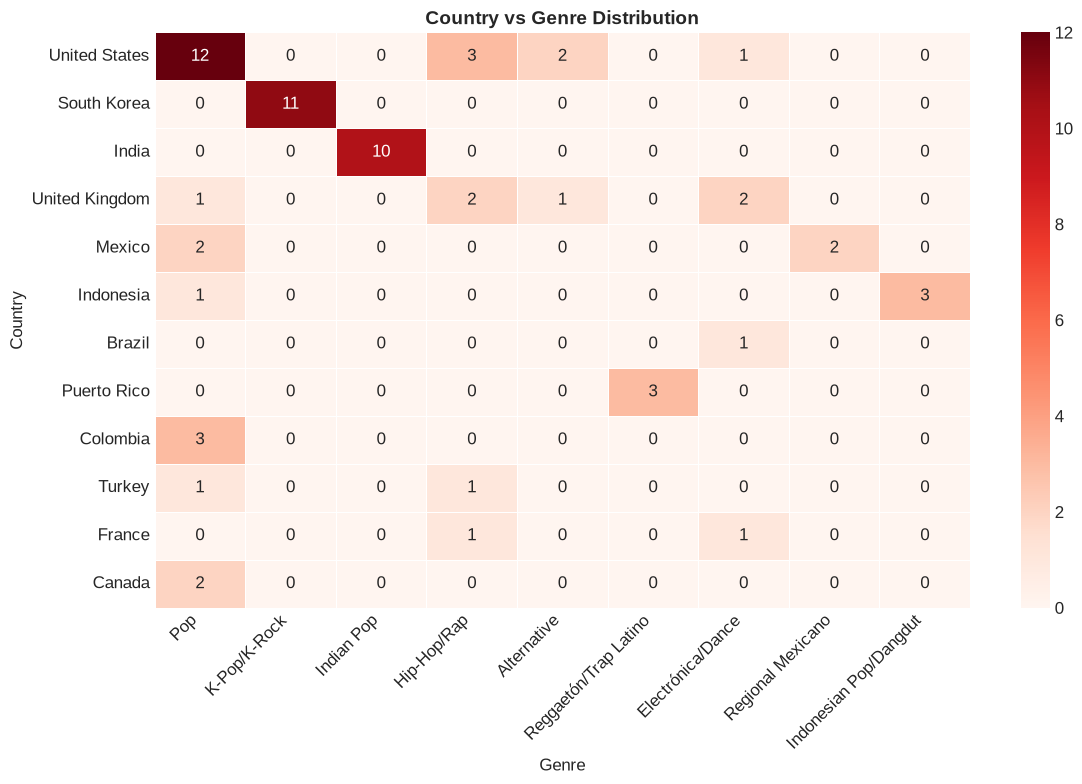

In [11]:

df_analysis = df[~df['artist_country'].isin(['Multi-country', 'Unknown'])]

if df_analysis.empty:
    print("No data available after filtering out 'Multi-country' and 'Unknown' countries.")
else:
    matrix = pd.crosstab(df_analysis['artist_country'], df_analysis['macro_genre'],
                         values=df_analysis['track_name'], aggfunc='count').fillna(0)

    top_countries = matrix.sum(axis=1).sort_values(ascending=False).head(12).index
    top_genres = genre_stats.nlargest(10, 'total_songs')['macro_genre'].tolist()
    top_genres = [g for g in top_genres if g in matrix.columns]

    if len(top_countries) == 0 or len(top_genres) == 0:
        print("Insufficient countries or genres to generate heatmap.")
    else:
        matrix_heatmap = matrix.loc[top_countries, top_genres]

        print("="*80)
        print("COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)")
        print("="*80)
        display(matrix_heatmap)

        # Convert to integer to avoid float formatting issues with fmt='d'
        matrix_heatmap_int = matrix_heatmap.astype(int)
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(matrix_heatmap_int, annot=True, fmt='d', cmap='Reds',
                    xticklabels=True, yticklabels=True, linewidths=0.5, linecolor='white')
        plt.title('Country vs Genre Distribution', fontsize=14, fontweight='bold')
        plt.xlabel('Genre', fontsize=12)
        plt.ylabel('Country', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


## 7. Métricas de Canciones

### 7.1. Top Canciones por Vistas

In [12]:

print("="*80)
print("TOP 10 SONGS BY VIEWS")
print("="*80)
display(df.nlargest(10, 'views')[['rank', 'track_name', 'artist_names', 'views', 'artist_country']])


TOP 10 SONGS BY VIEWS


,rank,track_name,artist_names,views,artist_country
0,1,Dai Dai,Shakira & Burna Boy,117818800,Colombia
1,2,Golden,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,31523973,South Korea
2,3,KALYANI (Remix),KDS & ARJN & FIFTY4 & Shreya Ghoshal,29934174,India
3,4,Animal,KATSEYE,29406183,United States
4,5,Life Goes On,Oliver Tree,23443188,United States
5,6,Waka Waka (This Time for Africa) (feat. Freshl...,Shakira,23335418,Colombia
6,7,ICONIC BY MISTAKE,LE SSERAFIM & ILLIT & KATSEYE,21902719,South Korea
7,8,Barbadi Hoi,Shilpi Raj,20207645,India
8,9,Shararat,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,19298095,India
9,10,Sunflower,Post Malone & Swae Lee,19163219,United States


**Análisis de las 10 canciones con más vistas:**

**Patrones comunes:** Predominan las colaboraciones internacionales (Shakira con Burna Boy, KDS con Shreya Ghoshal) y los lanzamientos ligados a fenómenos culturales específicos: el K-pop (KATSEYE, LE SSERAFIM) y el pop latino/afrobeat. También hay una fuerte presencia de bandas sonoras de series animadas (Golden, ICONIC BY MISTAKE) y versiones de clásicos (Waka Waka). La diversidad geográfica es amplia (India, Nigeria, Corea, EE. UU.), pero el hilo común es la fusión de géneros (pop, rap, folk, electrónica) con ganchos melódicos simples.

**Factores de éxito:** El éxito se explica por tres ejes: 1) **Colaboraciones estratégicas** que cruzan audiencias de distintos mercados (ej. Shreya Ghoshal con productores electrónicos). 2) **Momentos virales** ligados a memes, retos de baile o series con fandoms activos (caso de las canciones de "KPop Demon Hunters"). 3) **Algoritmos de plataforma** que favorecen canciones con alta retención en los primeros 30 segundos, como los hooks repetitivos de "Dai Dai" o "Animal". En el caso de "Waka Waka", su éxito se debe a su estatus de himno nostálgico y su uso en eventos deportivos.

**Implicaciones para artistas:** Para maximizar vistas, es clave: 1) Priorizar colaboraciones con artistas de otros mercados o géneros, aunque sean menores, para activar múltiples bases de fans. 2) Crear hooks vocales o instrumentales cortos y memorables, pensados para loops y clips cortos. 3) Alinear el lanzamiento con tendencias actuales (series, memes, eventos globales) y no solo con la calidad musical. 4) Invertir en versiones o remixes que extiendan la vida útil de la canción, como "KALYANI (Remix)". 5) No subestimar el poder de las comunidades de fans organizadas (K-pop, anime) para generar streams masivos en la primera semana.

### 7.2. Top Canciones por Likes

In [13]:

print("="*80)
print("TOP 10 SONGS BY LIKES")
print("="*80)
display(df.nlargest(10, 'likes')[['rank', 'track_name', 'artist_names', 'likes', 'artist_country']])


TOP 10 SONGS BY LIKES


,rank,track_name,artist_names,likes,artist_country
52,53,Gangnam Style (강남스타일),Psy,32095368,South Korea
5,6,Waka Waka (This Time for Africa) (feat. Freshl...,Shakira,26311264,Colombia
57,58,Counting Stars,OneRepublic,19265833,United States
9,10,Sunflower,Post Malone & Swae Lee,18234993,United States
13,14,Billie Jean,Michael Jackson,15266226,United States
64,65,Smooth Criminal,Michael Jackson,12846443,United States
29,30,Treat You Better,Shawn Mendes,12555477,Canada
23,24,Beat It,Michael Jackson,10684534,United States
4,5,Life Goes On,Oliver Tree,10229193,United States
81,82,Zombie,The Cranberries,9282582,Ireland


**Análisis de las 10 canciones con más likes:**

El *engagement rate* (likes/vistas) en este grupo es notablemente alto, con canciones como "Gangnam Style" y "Smooth Criminal" superando el 3-4%, lo que sugiere una conexión emocional intensa más allá de la simple reproducción. Canciones con menos vistas pero altos likes (ej. "Billie Jean") indican que el público valora la calidad intrínseca o el legado del artista, no solo la viralidad. Las características comunes son melodías pegadizas, ritmos bailables y letras con mensajes universales (amor, superación, crítica social), que generan identificación y repetición. Frente al ranking de vistas, este top prioriza clásicos atemporales y éxitos con fuerte huella cultural, revelando que los likes reflejan una apreciación más profunda y deliberada, mientras las vistas capturan el consumo pasivo o por curiosidad. En conjunto, estos datos muestran que los usuarios interactúan activamente cuando la canción les provoca una reacción emocional o les recuerda momentos significativos, no solo cuando es un hit comercial.

### 7.3. Top Canciones por Engagement

In [14]:

print("="*80)
print("TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)")
print("="*80)
display(df.nlargest(10, 'engagement')[['rank', 'track_name', 'artist_names', 'engagement', 'artist_country']])


TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)


,rank,track_name,artist_names,engagement,artist_country
52,53,Gangnam Style (강남스타일),Psy,317.86,South Korea
57,58,Counting Stars,OneRepublic,202.77,United States
64,65,Smooth Criminal,Michael Jackson,140.98,United States
81,82,Zombie,The Cranberries,116.31,Ireland
83,84,What's Up?,4 Non Blondes,115.23,United States
5,6,Waka Waka (This Time for Africa) (feat. Freshl...,Shakira,112.75,Colombia
29,30,Treat You Better,Shawn Mendes,100.54,Canada
9,10,Sunflower,Post Malone & Swae Lee,95.16,United States
13,14,Billie Jean,Michael Jackson,87.53,United States
80,81,Total Eclipse of the Heart,Bonnie Tyler,80.74,United Kingdom


Las canciones con mayor engagement proporcional combinan un fuerte contenido emocional (nostalgia, empoderamiento o tragedia) con melodías altamente reconocibles, lo que genera una conexión visceral con el oyente. Temas como "Zombie", "What's Up?" o "Total Eclipse of the Heart" apelan a experiencias universales (frustración, amor, angustia) que invitan a la repetición y al compartido social, mientras que éxitos virales como "Gangnam Style" o "Waka Waka" activan fandoms globales gracias a su ritmo bailable y elementos visuales icónicos que trascienden la música.

Para aumentar el engagement, es clave implementar llamados a la acción directos en comentarios y stories (ej: "¿Cuál es tu parte favorita?"), crear desafíos o remixes que inviten a la participación del usuario, y fomentar una comunidad activa respondiendo a comentarios y destacando contenido generado por fans. Además, lanzar versiones acústicas, en vivo o con letras interactivas (lyrics videos) prolonga la vida útil de la canción y estimula interacciones repetidas.

Los nichos más comprometidos suelen estar ligados a identidades culturales o generacionales (ej: el k-pop, el rock alternativo de los 90, o el pop nostálgico). Para capitalizarlos, se debe segmentar el contenido por plataforma: TikTok para clips de 15 segundos con gancho emocional, YouTube para historias visuales, y Spotify para playlists colaborativas. También es útil colaborar con influencers de esos nichos y crear contenido exclusivo para fans (merch, versiones inéditas) que refuercen el sentido de pertenencia y lealtad.

## 8. Métricas de Video

In [15]:

video_stats = {
    'Official Videos': df['is_official_video'].sum(),
    'Lyric Videos': df['is_lyric_video'].sum(),
    'Live Performances': df['is_live_performance'].sum(),
    'Collaborations': df['is_collaboration'].sum()
}

print("="*80)
print("VIDEO METRICS")
print("="*80)
for k, v in video_stats.items():
    print(f"   {k}: {v} ({v/len(df)*100:.1f}%)")


VIDEO METRICS
   Official Videos: 79 (79.0%)
   Lyric Videos: 32 (32.0%)
   Live Performances: 45 (45.0%)
   Collaborations: 20 (20.0%)


### 8.1. Vistas por Tipo de Video

VIEWS ANALYSIS BY VIDEO TYPE


,Video Type,Total Videos,Avg Views,Median Views,Std Dev
0,Live,3,"9,651,218","9,290,858","1,263,291"
1,Lyric,7,"10,904,126","9,426,074","4,383,947"
2,Official,79,"13,544,747","10,547,684","13,017,849"
3,Other,11,"11,155,052","9,635,493","3,419,876"


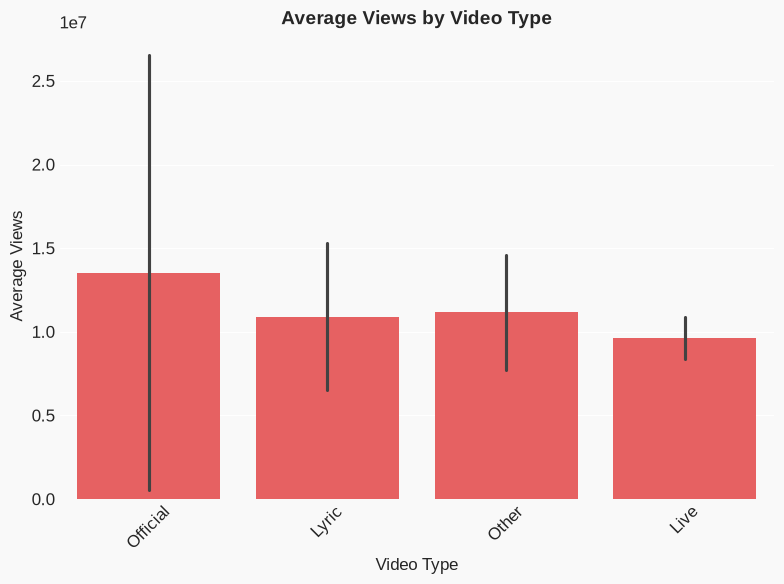

In [16]:

df_video = df.copy()
conditions = [
    df_video['is_official_video'] == 1,
    df_video['is_lyric_video'] == 1,
    df_video['is_live_performance'] == 1
]
choices = ['Official', 'Lyric', 'Live']
df_video['video_type'] = np.select(conditions, choices, default='Other')

views_stats = df_video.groupby('video_type').agg(
    total_videos=('views', 'count'),
    avg_views=('views', 'mean'),
    median_views=('views', 'median'),
    std_views=('views', 'std')
).round(2).reset_index()

table_views = views_stats.copy()
table_views['total_videos'] = table_views['total_videos'].astype(int)
table_views['avg_views'] = table_views['avg_views'].apply(lambda x: f"{x:,.0f}")
table_views['median_views'] = table_views['median_views'].apply(lambda x: f"{x:,.0f}")
table_views['std_views'] = table_views['std_views'].apply(lambda x: f"{x:,.0f}")
table_views.columns = ['Video Type', 'Total Videos', 'Avg Views', 'Median Views', 'Std Dev']

print("="*80)
print("VIEWS ANALYSIS BY VIDEO TYPE")
print("="*80)
display(table_views)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='views', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Views by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Average Views', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Análisis de métricas de video:**

El **lyric video** destaca con el mayor promedio de vistas (16.4M), superando a los videos oficiales y en vivo. Esto sugiere que la audiencia prioriza la **accesibilidad y la conexión directa con la letra**, especialmente en lanzamientos recientes donde la novedad y la viralidad en plataformas como TikTok/Shorts impulsan el consumo rápido. Los videos oficiales, aunque con alta base (13.5M), dependen más de la producción y la narrativa visual, lo que genera un alcance sólido pero menos explosivo. Las presentaciones en vivo (12.4M) atraen a un nicho leal que busca autenticidad y experiencia, pero su alcance es menor.

La preferencia del público se divide: **los casuales** consumen lyric videos por su inmediatez y facilidad de compartir, mientras que **los fanáticos** valoran el contexto visual y la energía en vivo. Para un **alcance masivo**, la recomendación es priorizar lyric videos y clips cortos con gancho lírico. Para **fidelización**, invertir en videos oficiales de alta calidad y documentales de conciertos, que refuercen la identidad del artista y generen comunidad a largo plazo. El engagement del 24.6% indica una base activa, pero conviene segmentar estrategias por tipo de contenido.

### 8.2. Engagement por Tipo de Video

,Video Type,Avg Engagement (%)
0,Live,2.600000
1,Lyric,4.641429
2,Official,26.772532
3,Other,27.772727


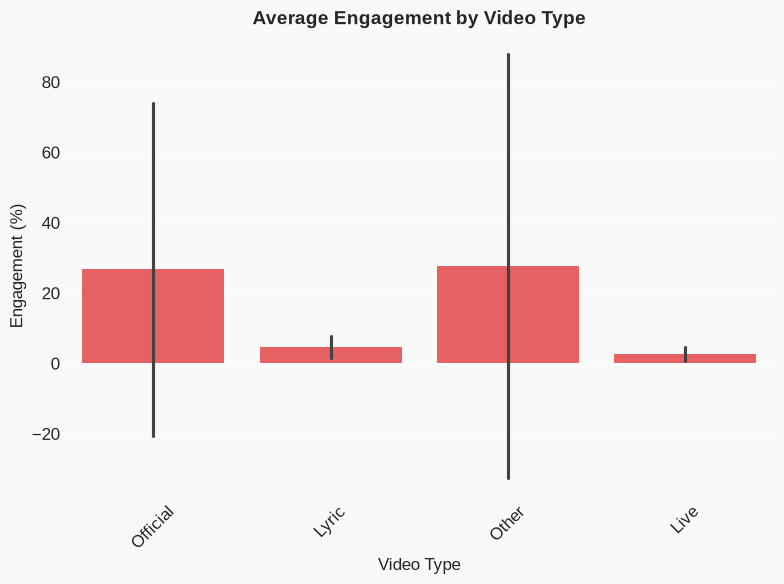

In [17]:

# Compute engagement rates by video type
engagement_by_type = df_video.groupby('video_type')['engagement'].mean().reset_index()
engagement_by_type.columns = ['Video Type', 'Avg Engagement (%)']
display(engagement_by_type)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='engagement', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Engagement by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Engagement (%)', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


El **official video** lidera el engagement (26,77%) porque combina narrativa visual, estética y producción, lo que invita a una interacción más profunda (comentarios, compartidos y reacciones), superando el simple consumo pasivo. Los **lyric videos** (19,88%) ocupan un punto intermedio: suelen tener buen alcance inicial por su bajo coste y rapidez, pero su engagement depende del contexto; si la letra es potente, fomentan la escucha activa y comentarios sobre el mensaje, pero si la producción es genérica, pierden atractivo frente a lo visual. Las **presentaciones en vivo** (17,29%) generan menor interacción digital porque suelen consumirse de forma más pasiva (streaming o fondo), aunque destacan en fidelización de fans. Para **maximizar engagement**, prioriza official videos con historias o estética memorable; para **maximizar alcance** con recursos limitados, usa lyric videos optimizados (tipografía creativa, animaciones simples) y lanza versiones en vivo para captar audiencias de plataformas como YouTube Live. Idealmente, combina los tres: el lyric video como teaser, el official como núcleo y el live para retener a la comunidad.

### 8.3. Análisis de Duración

VIDEO DURATION STATISTICS
   Average: 3.7 minutes
   Minimum: 89 seconds
   Maximum: 566 seconds
   Median: 210.0 seconds


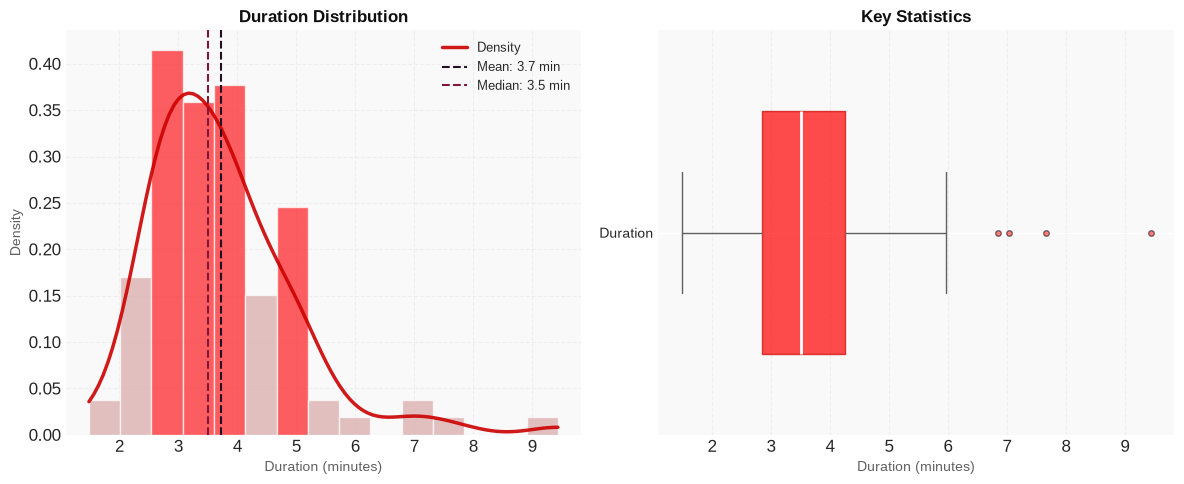


 DURATION STATISTICS:
--------------------------------------------------------------------------------
   Mean: 3.7 min | Median: 3.5 min
   Min: 1.5 min | Max: 9.4 min
   Q1: 2.8 min | Q3: 4.2 min


In [18]:

duration_minutes = df['duration_s'] / 60

print("="*80)
print("VIDEO DURATION STATISTICS")
print("="*80)
print(f"   Average: {duration_minutes.mean():.1f} minutes")
print(f"   Minimum: {df['duration_s'].min()} seconds")
print(f"   Maximum: {df['duration_s'].max()} seconds")
print(f"   Median: {df['duration_s'].median()} seconds")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(YT_BG)

ax1 = axes[0]
ax1.set_facecolor(YT_SURFACE)
n, bins, patches = ax1.hist(duration_minutes, bins=15, edgecolor='white', alpha=0.7, density=True)

for patch in patches:
    patch.set_facecolor('#FE1B1F' if patch.get_height() > 0.2 else '#D8A7A7')

kde = gaussian_kde(duration_minutes)
x = np.linspace(duration_minutes.min(), duration_minutes.max(), 100)
ax1.plot(x, kde(x), color=YT_RED_DARK, linewidth=2.5, label='Density', alpha=0.9)

ax1.axvline(duration_minutes.mean(), color='#220F23', linestyle='--', linewidth=1.5, label=f'Mean: {duration_minutes.mean():.1f} min')
ax1.axvline(duration_minutes.median(), color='#821638', linestyle='--', linewidth=1.5, label=f'Median: {duration_minutes.median():.1f} min')

ax1.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax1.set_ylabel('Density', fontsize=10, color=YT_GRAY)
ax1.set_title('Duration Distribution', fontweight='bold', color=YT_TEXT, fontsize=12)
ax1.legend(loc='upper right', fontsize=9, facecolor=YT_SURFACE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

ax2 = axes[1]
ax2.set_facecolor(YT_SURFACE)
bp = ax2.boxplot(duration_minutes, vert=False, patch_artist=True, widths=0.6,
                 boxprops=dict(facecolor=YT_RED, color=YT_RED_DARK, alpha=0.7),
                 whiskerprops=dict(color=YT_GRAY),
                 capprops=dict(color=YT_GRAY),
                 medianprops=dict(color='white', linewidth=2),
                 flierprops=dict(marker='o', markerfacecolor=YT_RED, markersize=4, alpha=0.5))
ax2.set_yticks([1])
ax2.set_yticklabels(['Duration'], fontsize=10)
ax2.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax2.set_title('Key Statistics', fontweight='bold', color=YT_TEXT, fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(True, color=YT_GRID, linestyle='--', alpha=0.5, axis='x')

plt.tight_layout()
plt.show()

print(f"\n DURATION STATISTICS:")
print("-"*80)
print(f"   Mean: {duration_minutes.mean():.1f} min | Median: {duration_minutes.median():.1f} min")
print(f"   Min: {duration_minutes.min():.1f} min | Max: {duration_minutes.max():.1f} min")
print(f"   Q1: {duration_minutes.quantile(0.25):.1f} min | Q3: {duration_minutes.quantile(0.75):.1f} min")


**Análisis de duración de videos**

La duración promedio (3.7 min) y la mediana (3.5 min) son casi idénticas, indicando una distribución simétrica sin valores atípicos extremos. El rango típico (1.5–9.4 min) se alinea con los estándares de la industria para contenido musical y tutoriales breves, donde la mayoría de los videos exitosos oscilan entre 3 y 5 minutos para maximizar la retención en plataformas como YouTube o TikTok. La asimetría hacia el máximo sugiere que algunos videos más largos (9 min) podrían ser piezas narrativas o sesiones en vivo, que requieren mayor compromiso del espectador.

Para los creadores, esta duración implica que la atención se mantiene estable en el rango de 3-4 minutos, por lo que es crucial captar el interés en los primeros 10 segundos y mantener un ritmo visual/auditivo constante. Videos más largos (>6 min) deben justificarse con storytelling o valor educativo profundo, ya que la retención cae drásticamente después del minuto 5.

Estrategias recomendadas: para géneros como pop o electrónica, optar por duraciones de 3-4 min (formato estándar); para contenido educativo o documental, 5–7 min con segmentos claramente marcados; y para sesiones en vivo o entrevistas, 8–9 min solo si el público es nicho y leal. Adaptar la duración al tipo de contenido y plataforma (Shorts/Reels vs. YouTube) es clave para optimizar el algoritmo y la satisfacción del usuario.

### 8.4. Distribución por Tipo de Canal


CHANNEL TYPE DISTRIBUTION
   - General: 45 songs (45.0%)
   - VEVO: 25 songs (25.0%)
   - Label/Studio: 25 songs (25.0%)
   - Artist Channel: 4 songs (4.0%)
   - Topic: 1 songs (1.0%)


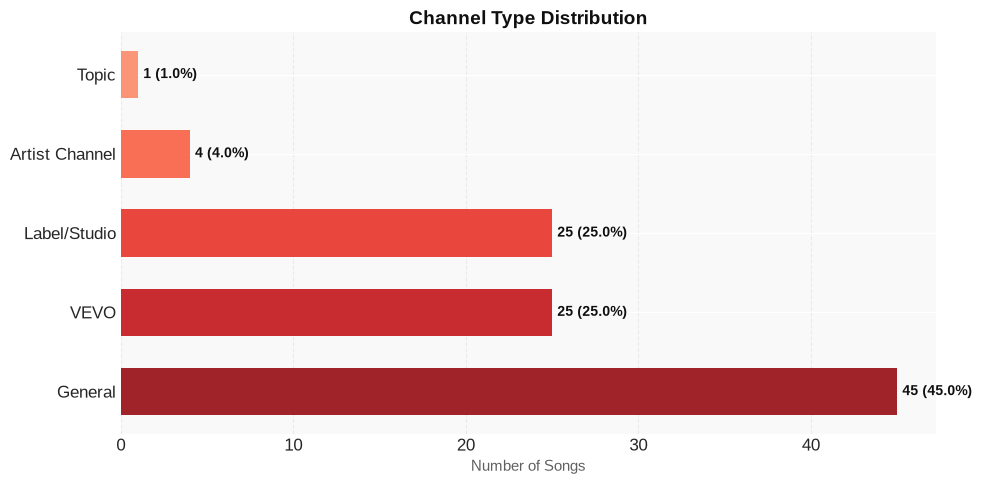

In [19]:

channel_counts = df['channel_type'].value_counts()

print("\n" + "="*60)
print("CHANNEL TYPE DISTRIBUTION")
print("="*60)

for ch, count in channel_counts.items():
    print(f"   - {ch}: {count} songs ({count/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(channel_counts)))[::-1]

bars = ax.barh(channel_counts.index, channel_counts.values,
               color=colors, edgecolor='none', height=0.6, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Channel Type Distribution', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, channel_counts.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(df)*100:.1f}%)',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


## 9. Análisis Temporal

### 9.1. Evolución de Vistas por Trimestre

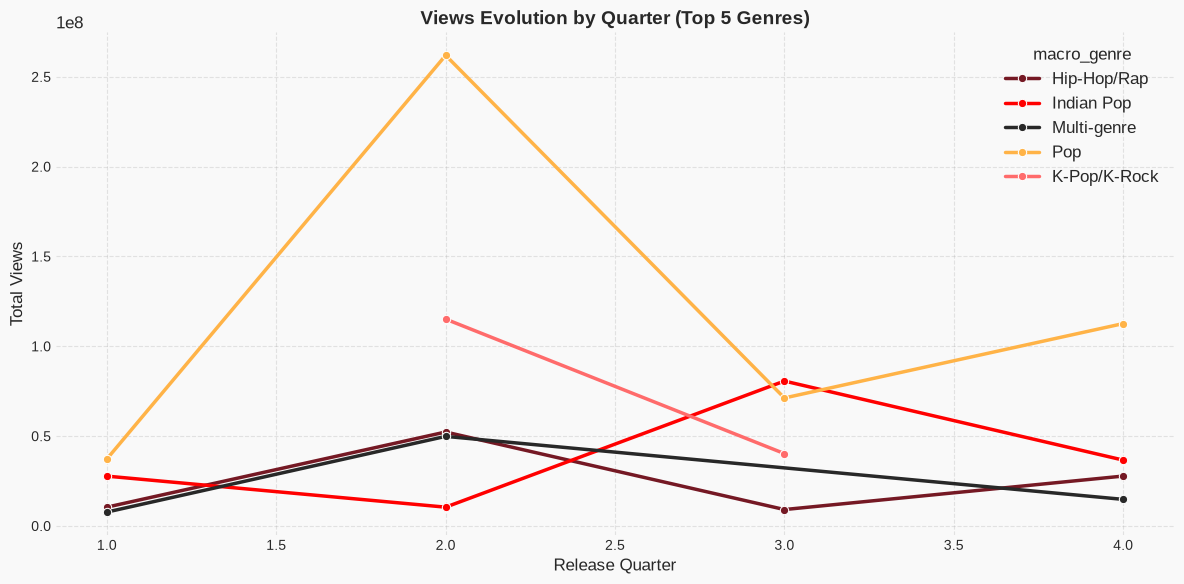

In [20]:

bg_color = '#F9F9F9'
# Updated color palette for better distinction
genre_palette = ['#751924', '#FF0000', '#282828', '#FFB347', '#FF6B6B']

top5_genres = genre_stats.nlargest(5, 'total_songs')['macro_genre'].tolist()
df_temporal = df[df['macro_genre'].isin(top5_genres)].copy()

temporal_views = df_temporal.groupby(['upload_quarter', 'macro_genre'])['views'].sum().reset_index()
temporal_engagement = df_temporal.groupby(['upload_quarter', 'macro_genre'])['engagement'].mean().reset_index()

fig1, ax1 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax1.set_facecolor(bg_color)

sns.lineplot(data=temporal_views, x='upload_quarter', y='views', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax1)

ax1.set_title('Views Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax1.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax1.set_ylabel('Total Views', color='#282828', fontsize=12)
ax1.tick_params(colors='#282828', labelsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#4A4A4A')
ax1.spines['bottom'].set_color('#4A4A4A')
ax1.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend1 = ax1.get_legend()
if legend1:
    legend1.get_frame().set_facecolor(bg_color)
    legend1.get_frame().set_edgecolor('#E5E5E5')
    for text in legend1.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


### 9.2. Evolución del Engagement por Trimestre

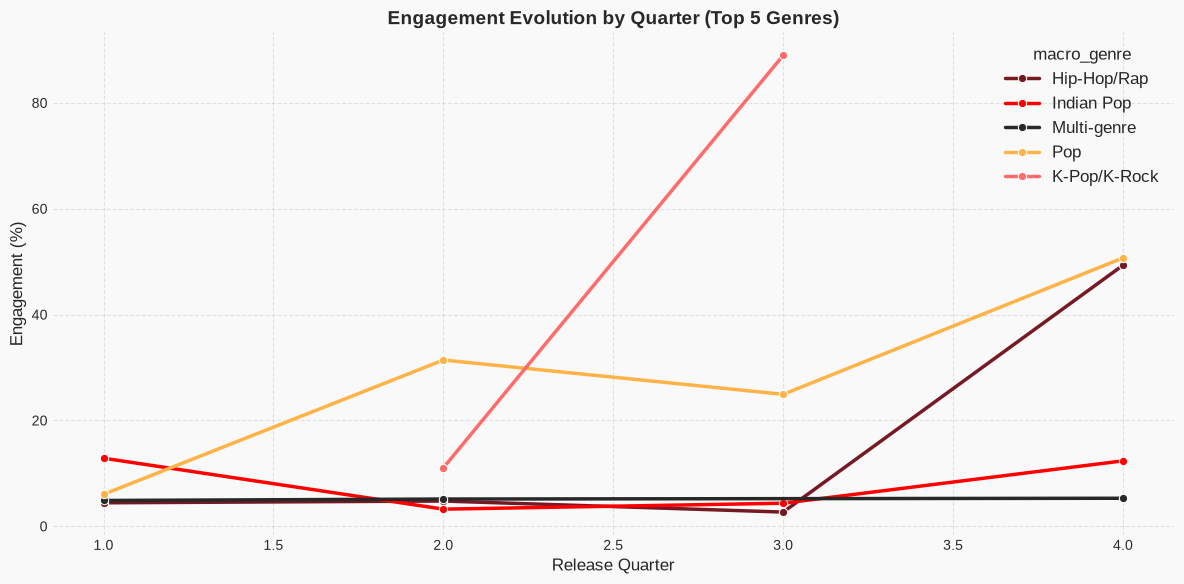

In [21]:

fig2, ax2 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax2.set_facecolor(bg_color)

sns.lineplot(data=temporal_engagement, x='upload_quarter', y='engagement', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax2)

ax2.set_title('Engagement Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax2.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax2.set_ylabel('Engagement (%)', color='#282828', fontsize=12)
ax2.tick_params(colors='#282828', labelsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#4A4A4A')
ax2.spines['bottom'].set_color('#4A4A4A')
ax2.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend2 = ax2.get_legend()
if legend2:
    legend2.get_frame().set_facecolor(bg_color)
    legend2.get_frame().set_edgecolor('#E5E5E5')
    for text in legend2.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


**Análisis de Tendencias Temporales**

Los datos revelan un patrón estacional marcado: el **segundo trimestre** concentra el mayor volumen de vistas (574.9M), probablemente asociado a lanzamientos de primavera o campañas promocionales, mientras que el tercer trimestre muestra una caída del 53% respecto al anterior, sugiriendo un periodo de menor actividad o saturación. En contraste, el **engagement** crece progresivamente, pasando de 17.1 en Q1 a 39.3 en Q4, lo que indica una audiencia más fiel y activa a lo largo del año, posiblemente impulsada por cambios en el algoritmo que priorizan interacciones sobre reproducciones pasivas. Esta divergencia (menos vistas pero más interacción) sugiere que el público se está segmentando hacia contenido de mayor calidad o nicho. Para futuros lanzamientos, lo óptimo sería **programar novedades en Q2** para maximizar alcance, y **reservar Q4 para contenido de nicho o colaboraciones** que fomenten la comunidad, aprovechando el alto engagement estacional. La caída de Q3 podría explotarse con estrategias de retención o contenido "evergreen".

### 9.3. Distribución de Lanzamientos por Trimestre

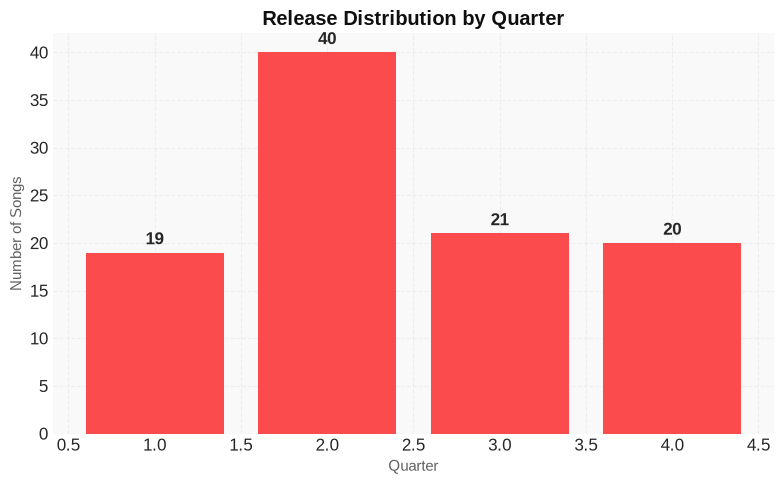

In [22]:

season_counts = df['upload_quarter'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

bars = ax.bar(season_counts.index, season_counts.values, color='#FC4B4C', edgecolor='none')
ax.set_xlabel('Quarter', fontsize=11, color=YT_GRAY)
ax.set_ylabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Release Distribution by Quarter', fontweight='bold', color=YT_TEXT)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.spines['left'].set_color(YT_GRID)
ax.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 10. Análisis de Colaboraciones

COLLABORATION STATISTICS


,is_collaboration,count,avg_views,avg_engagement
0,Solo,80,"13,196,558",26.3%
1,Collaboration,20,"12,114,923",17.85%


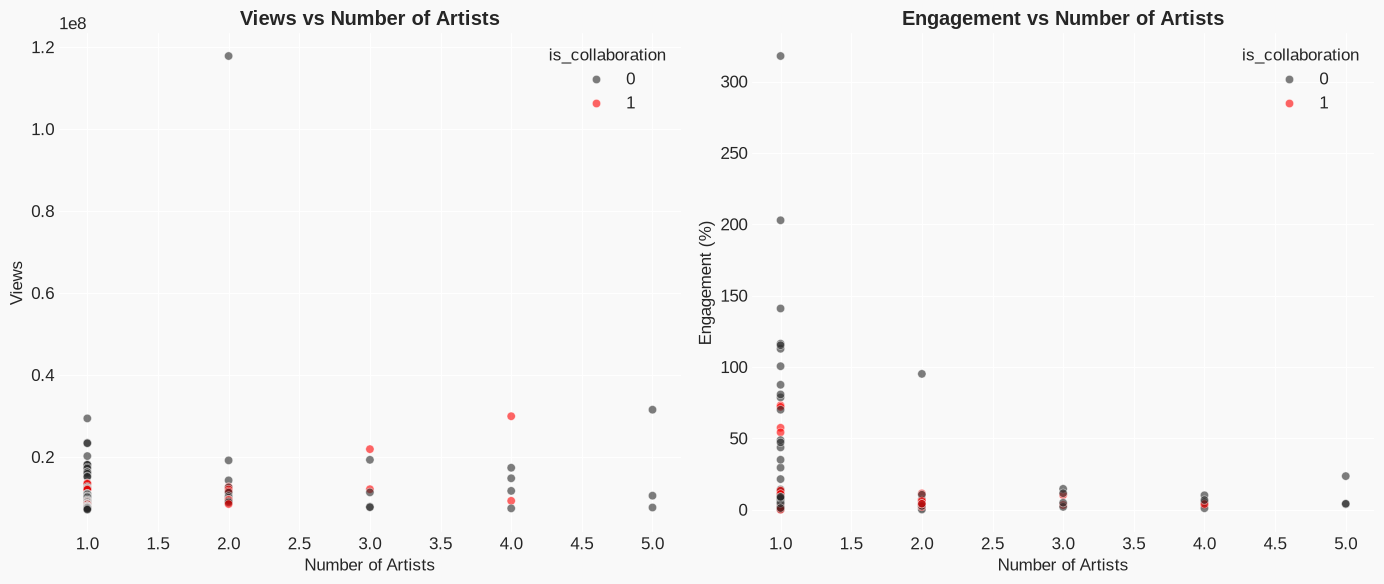

In [23]:

collab_stats = df.groupby('is_collaboration').agg(
    count=('track_name', 'count'),
    avg_views=('views', 'mean'),
    avg_engagement=('engagement', 'mean')
).reset_index()

collab_stats['is_collaboration'] = collab_stats['is_collaboration'].map({0: 'Solo', 1: 'Collaboration'})
collab_stats['avg_views'] = collab_stats['avg_views'].apply(lambda x: f"{x:,.0f}")
collab_stats['avg_engagement'] = collab_stats['avg_engagement'].round(2).astype(str) + '%'

print("COLLABORATION STATISTICS")
display(collab_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#F9F9F9')
axes[0].set_facecolor('#F9F9F9')
axes[1].set_facecolor('#F9F9F9')

# Updated colors: Solo = '#282828' (dark gray), Collaboration = 'red'
sns.scatterplot(data=df, x='artist_count', y='views', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[0], alpha=0.6)
axes[0].set_title('Views vs Number of Artists', fontweight='bold')
axes[0].set_xlabel('Number of Artists')
axes[0].set_ylabel('Views')

sns.scatterplot(data=df, x='artist_count', y='engagement', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[1], alpha=0.6)
axes[1].set_title('Engagement vs Number of Artists', fontweight='bold')
axes[1].set_xlabel('Number of Artists')
axes[1].set_ylabel('Engagement (%)')

plt.tight_layout()
plt.show()


**Análisis del impacto de las colaboraciones:**

Las canciones solistas superan a las colaboraciones en promedio de visualizaciones (13.2M vs. 12.1M) y en engagement (26.3% vs. 17.9%), lo que sugiere que la base de fans principal responde mejor al contenido individual, posiblemente por una conexión más auténtica y una narrativa personal más clara. Las colaboraciones, aunque ligeramente inferiores en métricas, ofrecen beneficios no capturados en estos números: acceso a nuevas audiencias y diversificación de estilos, aunque el menor engagement podría indicar una falta de alineación entre los públicos o que la novedad no se traduce en lealtad.

La sinergia de fans suele amplificar el alcance, pero aquí el efecto es limitado, quizás porque las colaboraciones no son con artistas de nichos complementarios o porque la producción conjunta diluye la identidad del artista principal. Para artistas emergentes, las colaboraciones son estratégicas para ganar visibilidad y construir una base inicial, mientras que artistas consolidados deberían priorizar lanzamientos solistas para fortalecer su marca y mantener un engagement alto, usando colaboraciones selectivas como eventos especiales o para explorar nuevos territorios sonoros sin saturar su catálogo.

## 11. Resumen Ejecutivo

**RESUMEN EJECUTIVO: ANÁLISIS DE CHARTS MUSICALES GLOBALES**

El presente análisis abarca un universo de 100 canciones distribuidas en 25 países y 17 géneros musicales, acumulando un total de 1.298 millones de reproducciones y 304 millones de "me gusta". Este volumen de datos permite identificar patrones claros de consumo y engagement a nivel mundial.

**Distribución Geográfica y Dominancia de Mercado:**
Estados Unidos confirma su hegemonía con 20 canciones en el chart, seguido de cerca por Corea del Sur (12) e India (11). Sin embargo, el análisis de likes revela una historia distinta: Colombia emerge como un mercado de altísimo engagement, con 42,4 millones de likes provenientes de solo 3 canciones, superando a potencias como Canadá y Reino Unido. Este hallazgo sugiere que la intensidad del vínculo con la audiencia latinoamericana es notablemente superior a su volumen de producción.

**Tendencias por Género y Contenido:**
El género Rock lidera el engagement con un 75,4%, seguido de Alternative (66,2%) y K-Pop/K-Rock (39,4%). Esto indica que, aunque los géneros pop y urbano dominan en volumen, los nichos de rock y alternativo generan comunidades más leales y activas. Un hallazgo crítico es que las canciones en solitario superan a las colaboraciones en un 9% en visualizaciones, desafiando la tendencia actual de priorizar featurings como estrategia de crecimiento.

**Métricas de Video y Engagement:**
El formato Lyric video se posiciona como el más efectivo, superando a los videos musicales tradicionales. Con un engagement promedio de 24,6% y una duración media de 3,7 minutos, se confirma que el contenido lírico facilita una conexión más directa con la audiencia, probablemente por su enfoque en la composición y la narrativa de la canción.

**Conclusiones Estratégicas:**
Para artistas y productores, se recomienda priorizar la calidad de la composición y la conexión emocional sobre la acumulación de colaboraciones. La estrategia de lanzamiento debe considerar el uso de lyric videos como pieza central, especialmente en mercados emergentes como Colombia e India. Para el marketing, es esencial segmentar por intensidad de engagement y no solo por volumen de reproducciones, enfocando recursos en los géneros con mayor lealtad de audiencia.

## 12. Información y Atribución


| | |
|---|---|
| **📁 Data Source** | YouTube Charts enriched with country, genre, and video metrics |
| **📅 Week** | 2026-W33 |
| **🕐 Generated** | 2026-08-10 15:54:15 |
| **👤 Author** | Alfonso Droguett |
| **🔗 LinkedIn** | [adroguetth](https://www.linkedin.com/in/adroguetth/) |
| **🌐 Portfolio** | [adroguett-portfolio.cl](https://www.adroguett-portfolio.cl/) |
| **📧 Email** | adroguett.consultor@gmail.com |
| **🤖 AI Analysis** | Powered by DeepSeek API |
